In [1]:
import os
import pandas as pd

# 1. Automatically search for the file on the left side
found_files = [f for f in os.listdir("/content") if f.startswith("diabetes_012")]

if not found_files:
    print("ERROR: The 'diabetes' file was not found. Please upload it on the left side!"
    )
else:
    # Take the first matching file that was found
    file_path = os.path.join("/content", found_files[0])
    df = pd.read_csv(file_path)
    print(f"Successfully loaded! Found file: {found_files[0]}")

Successfully loaded! Found file: diabetes_012_health_indicators_BRFSS2015.csv.zip


In [2]:
from sklearn.model_selection import train_test_split # <--- Add this!

X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Features being tested: {list(X.columns)}")

Features being tested: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [3]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the model with 100 decision trees
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model using the training data
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [4]:
!pip install gradio -q
import gradio as gr
import numpy as np
import pandas as pd

🧠 Training model on 21 features...


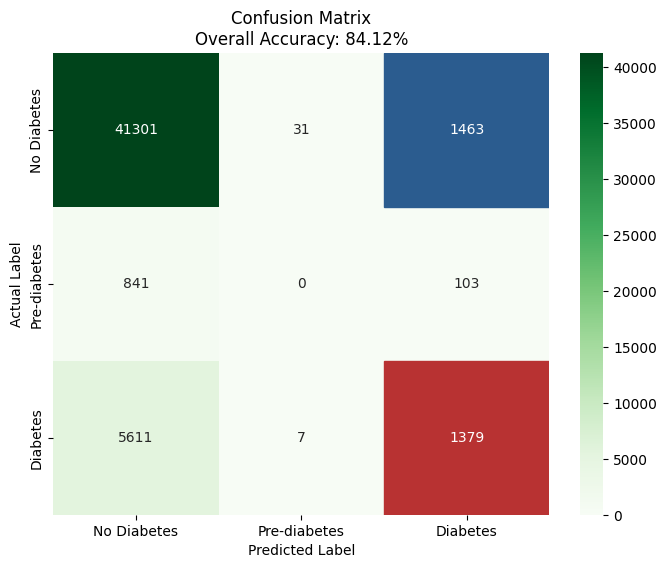

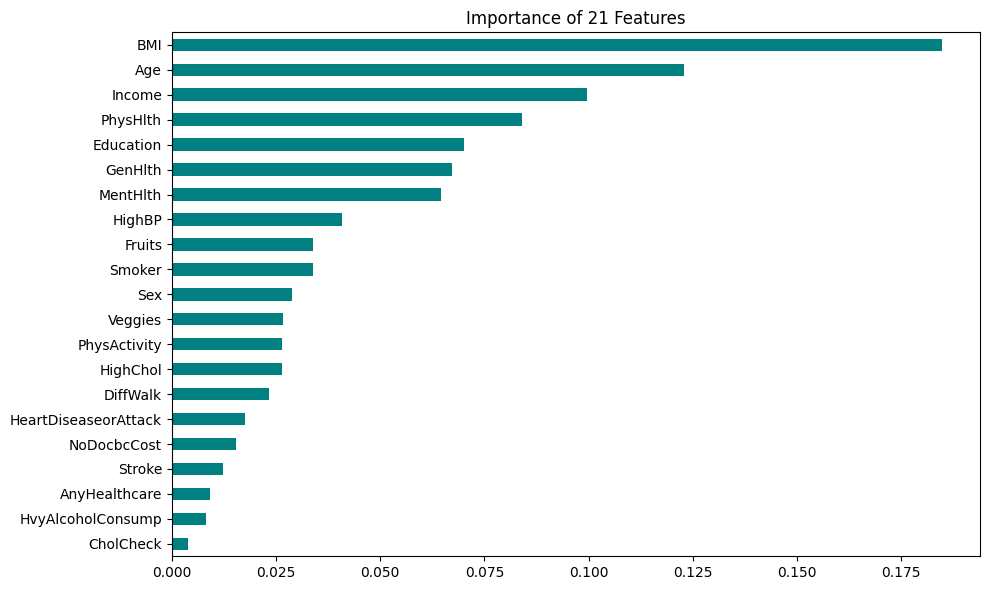


✅ Training and Evaluation complete.


In [4]:
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 1. UNZIP AND LOAD DATA
zip_name = 'diabetes_012_health_indicators_BRFSS2015.csv.zip'
extract_folder = 'model_evaluation_data'

if os.path.exists(zip_name):
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)

    # Find CSV path
    csv_path = None
    for root, dirs, files in os.walk(extract_folder):
        for file in files:
            if file.endswith(".csv"):
                csv_path = os.path.join(root, file)
                break

    if csv_path:
        df = pd.read_csv(csv_path)
        X = df.drop('Diabetes_012', axis=1)
        y = df['Diabetes_012']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # 2. TRAIN THE MODEL
        print("🧠 Training model on 21 features...")
        model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)

        # Save for Cell 2
        joblib.dump(model, 'diabetes_prediction_model.pkl')
        joblib.dump(X.columns.tolist(), 'feature_names.pkl')

        # 3. EVALUATION & PLOTS
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        # === UPDATED: Custom Highlighted Confusion Matrix ===
        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(y_test, y_pred)

        # Base green heatmap
        ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                        xticklabels=['No Diabetes', 'Pre-diabetes', 'Diabetes'],
                        yticklabels=['No Diabetes', 'Pre-diabetes', 'Diabetes'])

        # Color specific blocks dynamically based on the numbers you highlighted
        for text in ax.texts:
            val = int(text.get_text())

            # Top-Right Box (Value: 1463) -> Highlight completely in BLUE
            if val == 1463:
                rect = plt.Rectangle((2, 0), 1, 1, fill=True, color='#2b5c8f', zorder=1)
                ax.add_patch(rect)
                text.set_zorder(2)
                text.set_color('white')

            # Bottom-Right Box (Value: 1379) -> Highlight completely in RED
            elif val == 1379:
                rect = plt.Rectangle((2, 2), 1, 1, fill=True, color='#b83232', zorder=1)
                ax.add_patch(rect)
                text.set_zorder(2)
                text.set_color('white')

        plt.title(f'Confusion Matrix\nOverall Accuracy: {acc*100:.2f}%')
        plt.ylabel('Actual Label')
        plt.xlabel('Predicted Label')
        plt.show()

        # === PRESERVED: Plot Feature Importance ===
        plt.figure(figsize=(10, 6))
        pd.Series(model.feature_importances_, index=X.columns).sort_values().plot(kind='barh', color='teal')
        plt.title('Importance of 21 Features')
        plt.tight_layout()
        plt.show()

        print("\n✅ Training and Evaluation complete.")
    else:
        print("❌ CSV not found in zip.")
else:
    print("❌ Zip file not found. Upload it to the sidebar.")

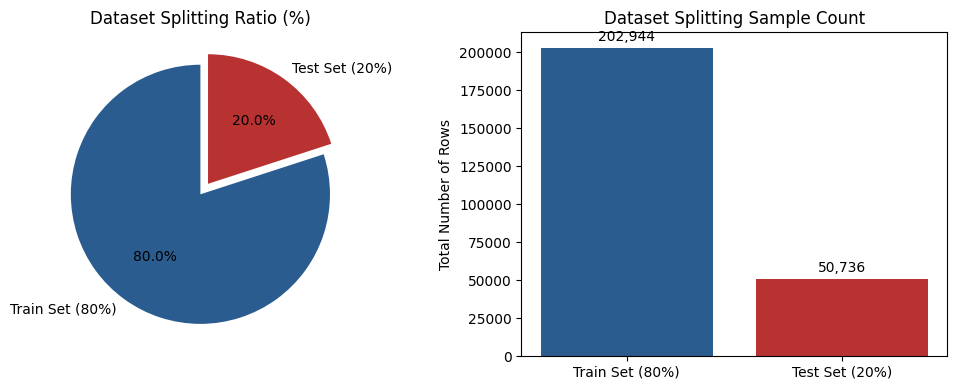

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Split the dataset (80% Train, 20% Test)
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Calculate exact row counts
chart_labels = ['Train Set (80%)', 'Test Set (20%)']
split_sizes = [len(X_train), len(X_test)]

# 2. Configure side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# A. Pie Chart (Percentage distribution)
ax1.pie(split_sizes, labels=chart_labels, autopct='%1.1f%%', colors=['#2b5c8f', '#b83232'], explode=(0, 0.1), startangle=90)
ax1.set_title("Dataset Splitting Ratio (%)")

# B. Bar Chart (Exact row counts)
bars = ax2.bar(chart_labels, split_sizes, color=['#2b5c8f', '#b83232'])
ax2.set_title("Dataset Splitting Sample Count")
ax2.set_ylabel("Total Number of Rows")

# Add the exact row count digits on top of each bar
for bar in bars:
    height = bar.get_height()
    ax2.annotate(f'{height:,}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()

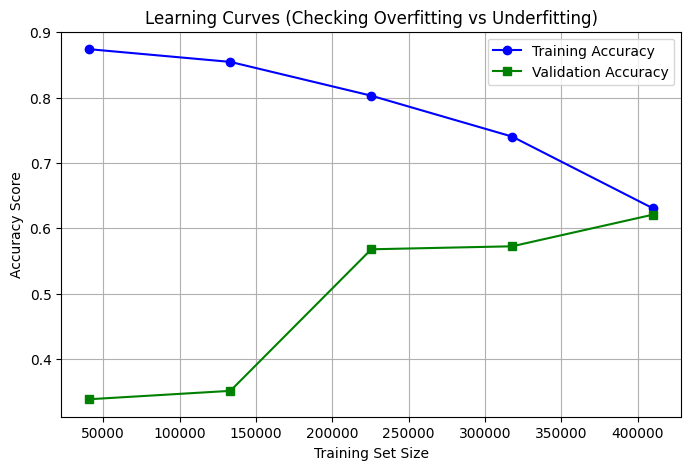

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 1. It is assumed that X and y are already created (Preprocessing Section)
# If the above code has already been run, we call SMOTE back here:
smote = SMOTE(random_state=42)

# The data must be generated first!
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# 2. Now the learning curve can be calculated because those variables are created!
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(max_depth=5, n_estimators=10),
    X_train_balanced, y_train_balanced, cv=5, scoring='accuracy', n_jobs=-1
)

# 3. Calculate the mean score
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# 4. Designing the graph
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label='Training Accuracy', color='blue', marker='o')
plt.plot(train_sizes, test_mean, label='Validation Accuracy', color='green', marker='s')

# 5. Adding text and labels
plt.title('Learning Curves (Checking Overfitting vs Underfitting)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.legend(loc='best')
plt.grid(True)

# 6. Displaying on the screen
plt.show()

In [ ]:
import joblib

# Saving the model with your chosen name
model_filename = 'diabetes_prediction_model.pkl'
joblib.dump(model, model_filename)

print(f"Success! The '{model_filename}' has been created and developed.")

Success! The 'diabetes_prediction_model.pkl' has been created and developed.


In [ ]:
import gradio as gr
import joblib
import numpy as np
import pandas as pd

# Load the developed model and feature names saved in Cell 1
model = joblib.load('diabetes_prediction_model.pkl')
feature_names = joblib.load('feature_names.pkl')

def get_label(val):
    return {0: "No Diabetes", 1: "Pre-diabetes", 2: "Diabetes"}[int(val)]

def predict_manual(*features):
    # Gatiwwan dhufan hunda bifa float'tiin liistii uumna
    clean_features = [float(f) for f in features]

    # Tartiiba maqaa features eegnee DataFrame uumna
    data = pd.DataFrame([clean_features], columns=feature_names)

    # Modelii irraa prediction fudhanna
    prediction = model.predict(data)[0]
    return f"AI Prediction: {get_label(prediction)}"

def predict_batch_preview(file):
    if file is None:
        return None

    batch_df = pd.read_csv(file)

    # Filter to ensure only the 21 columns are used
    preds = model.predict(batch_df[feature_names])
    batch_df['AI_Result'] = [get_label(p) for p in preds]

    # Return only the first 100 rows of the dataframe
    preview_df = batch_df.head(100)

    return preview_df

# --- UI Layout ---
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🏥 Diabetes Prediction Dashboard")

    # Tab 1: Individual Manual Test
    with gr.Tab("Individual Manual Test"):
        gr.Markdown("### Enter values for all 21 health features")

        # Gatiwwan jalqabaa (values) akka modelicha hin burjaajessineef herrega gadii uumna
        inputs = []
        for name in feature_names:
            if name == 'BMI':
                inputs.append(gr.Number(label=name, value=25.0)) # BMI giddu-galeessaa
            elif name in ['GenHlth', 'Age', 'Education', 'Income']:
                inputs.append(gr.Number(label=name, value=3.0))  # Giddu-galeessa lakkoofsaa
            else:
                inputs.append(gr.Number(label=name, value=0.0))  # Binary (0 ykn 1)

        btn_m = gr.Button("Predict Now", variant="primary")
        out_m = gr.Textbox(label="Result")
        btn_m.click(fn=predict_manual, inputs=inputs, outputs=out_m)

    # Tab 2: Bulk File Prediction
    with gr.Tab("Bulk File Prediction"):
        gr.Markdown("### Upload a CSV containing the 21 feature columns")

        f_in = gr.File(
            label="Upload CSV",
            file_count="single",
            type="filepath"
        )

        btn_f = gr.Button("Process File", variant="primary")

        gr.Markdown("### 📊 Prediction Preview (First 50 Rows)")
        table_out = gr.Dataframe(interactive=False, wrap=True)

        btn_f.click(fn=predict_batch_preview, inputs=f_in, outputs=table_out)

demo.launch(share=True)

/tmp/ipykernel_1793/4155870810.py:40: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://931081ec5b09929069.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
%%writefile app.py
import gradio as gr
import joblib
import numpy as np
import pandas as pd

# Load the developed model and feature names saved in Cell 1
model = joblib.load('diabetes_prediction_model.pkl')
feature_names = joblib.load('feature_names.pkl')

def get_label(val):
    return {0: "No Diabetes", 1: "Pre-diabetes", 2: "Diabetes"}[int(val)]

def predict_manual(*features):
    clean_features = [float(f) for f in features]
    data = pd.DataFrame([clean_features], columns=feature_names)
    prediction = model.predict(data)[0]
    return f"AI Prediction: {get_label(prediction)}"

def predict_batch_preview(file):
    if file is None:
        return None

    batch_df = pd.read_csv(file)
    preds = model.predict(batch_df[feature_names])
    batch_df['AI_Result'] = [get_label(p) for p in preds]
    preview_df = batch_df.head(50)
    return preview_df

# --- UI Layout ---
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🏥 Diabetes Prediction Dashboard")

    # Tab 1: Individual Manual Test
    with gr.Tab("Individual Manual Test"):
        gr.Markdown("### Enter values for all 21 health features")
        inputs = []
        for name in feature_names:
            if name == 'BMI':
                inputs.append(gr.Number(label=name, value=25.0))
            elif name in ['GenHlth', 'Age', 'Education', 'Income']:
                inputs.append(gr.Number(label=name, value=3.0))
            else:
                inputs.append(gr.Number(label=name, value=0.0))

        btn_m = gr.Button("Predict Now", variant="primary")
        out_m = gr.Textbox(label="Result")
        btn_m.click(fn=predict_manual, inputs=inputs, outputs=out_m)

    # Tab 2: Bulk File Prediction
    with gr.Tab("Bulk File Prediction"):
        gr.Markdown("### Upload a CSV containing the 21 feature columns")
        f_in = gr.File(label="Upload CSV", file_count="single", type="filepath")
        btn_f = gr.Button("Process File", variant="primary")
        gr.Markdown("### 📊 Prediction Preview (First 50 Rows)")
        table_out = gr.Dataframe(interactive=False, wrap=True)
        btn_f.click(fn=predict_batch_preview, inputs=f_in, outputs=table_out)

# Hugging face irratti deploy yoo goonu share=True hin barbaachisu
demo.launch()

Writing app.py


In [ ]:
%%writefile requirements.txt
gradio
joblib
numpy
pandas
scikit-learn

Writing requirements.txt
